In [2]:
import qiskit

In [3]:
qiskit.__version__

'1.4.2'

In [4]:
token = "MK9bZuASn2QEw3VvroU7qg3AVjaRfq07O4U6qsJwPZ5F"

In [5]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService.save_account(
    channel="ibm_cloud",    # or "ibm_quantum"
    token=token,            # IBM Cloud API key
    instance="instance1",       # <-- this should be your *CRN* or instance name
    name="default",      # optional
    set_as_default=True,
    overwrite=True
)

In [6]:
service = QiskitRuntimeService()
print(service.backends())

[<IBMBackend('ibm_brisbane')>, <IBMBackend('ibm_torino')>]


In [7]:
service.backends(simulator=False, operational=True, min_num_qubits=5)

[<IBMBackend('ibm_brisbane')>, <IBMBackend('ibm_torino')>]

In [8]:
service.least_busy(operational=True, min_num_qubits=5)

<IBMBackend('ibm_torino')>

In [9]:
backend = service.backend("ibm_brisbane")
 
print(
    f"Name: {backend.name}\n"
    f"Version: {backend.version}\n"
    f"No. of qubits: {backend.num_qubits}\n"
)

Name: ibm_brisbane
Version: 2
No. of qubits: 127



In [10]:
 from qiskit import QuantumCircuit
 from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
 
 # Create empty circuit
 example_circuit = QuantumCircuit(2)
 example_circuit.measure_all()
 
 # You'll need to specify the credentials when initializing QiskitRuntimeService, if they were not previously saved.
 service = QiskitRuntimeService()
 backend = service.backend("ibm_brisbane")
 sampler = Sampler(backend)
 job = sampler.run([example_circuit])
 print(f"job id: {job.job_id()}")
 result = job.result()
 print(result)

job id: d3lqemb4kkus739d1640
PrimitiveResult([SamplerPubResult(data=DataBin(meas=BitArray(<shape=(), num_shots=4096, num_bits=2>)), metadata={'circuit_metadata': {}})], metadata={'execution': {'execution_spans': {'__type__': 'ExecutionSpans', '__value__': {'spans': [DoubleSliceSpan(<start='2025-10-12 13:04:27', stop='2025-10-12 13:04:29', size=4096>)]}}}, 'version': 2})


In [11]:
from qiskit import QuantumCircuit
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
 
# Create empty circuit
example_circuit = QuantumCircuit(2)
example_circuit.measure_all()
 
# You'll need to specify the credentials when initializing QiskitRuntimeService, if they were not previously saved.
service = QiskitRuntimeService()
backend = service.least_busy(operational=True, simulator=False)
 
sampler = Sampler(backend)
job = sampler.run([example_circuit])
print(f"job id: {job.job_id()}")
result = job.result()
print(result)

job id: d3lqepj4kkus739d1670
PrimitiveResult([SamplerPubResult(data=DataBin(meas=BitArray(<shape=(), num_shots=4096, num_bits=2>)), metadata={'circuit_metadata': {}})], metadata={'execution': {'execution_spans': {'__type__': 'ExecutionSpans', '__value__': {'spans': [DoubleSliceSpan(<start='2025-10-12 13:04:40', stop='2025-10-12 13:04:42', size=4096>)]}}}, 'version': 2})


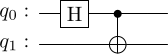

In [12]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import EstimatorV2 as Estimator
 
# Create a new circuit with two qubits
qc = QuantumCircuit(2)
 
# Add a Hadamard gate to qubit 0
qc.h(0)
 
# Perform a controlled-X gate on qubit 1, controlled by qubit 0
qc.cx(0, 1)
 
# Return a drawing of the circuit using MatPlotLib ("mpl"). This is the
# last line of the cell, so the drawing appears in the cell output.
# Remove the "mpl" argument to get a text drawing.
qc.draw("latex")

In [13]:
#Simulate and measure bell state on available device

from qiskit import transpile
from qiskit_ibm_runtime import Session
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

Measurement results: {'01': 1900, '10': 2110, '00': 59, '11': 27}


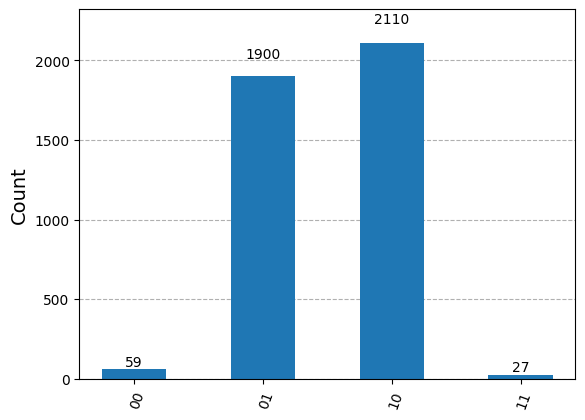

In [14]:
#|psi+>
qc = QuantumCircuit(2, 2)
qc.x(1)
qc.h(0)
qc.cx(0, 1)
qc.measure([0, 1], [0, 1])

backend = service.least_busy(simulator=False)
qc_transpiled = transpile(qc, backend=backend)

sampler = Sampler(backend)
job = sampler.run([qc_transpiled])
result = job.result()

counts = result[0].data.c.get_counts()
print("Measurement results:", counts)

plot_histogram(counts)

Measurement results: {'10': 2110, '01': 1890, '11': 31, '00': 65}


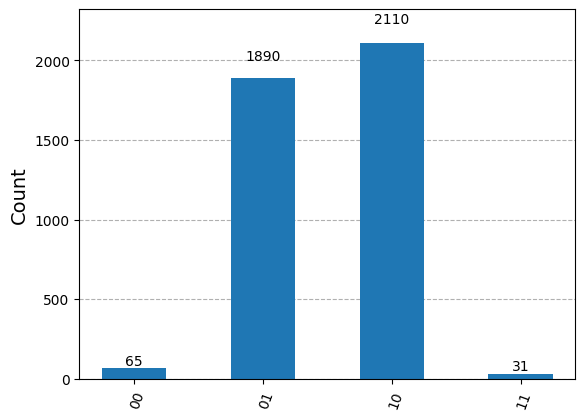

In [15]:
#|psi->
qc = QuantumCircuit(2, 2)
qc.x(1)
qc.h(0)
qc.cx(0, 1)
qc.z(0)
qc.measure([0, 1], [0, 1])

backend = service.least_busy(simulator=False)
qc_transpiled = transpile(qc, backend=backend)

sampler = Sampler(backend)
job = sampler.run([qc_transpiled])
result = job.result()

counts = result[0].data.c.get_counts()
print("Measurement results:", counts)

plot_histogram(counts)

Measurement results: {'11': 1873, '00': 2137, '01': 51, '10': 35}


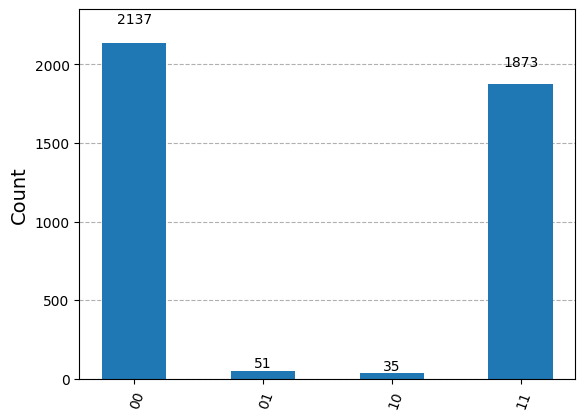

In [16]:
#|phi+>
qc = QuantumCircuit(2, 2)
qc.h(0)
qc.cx(0, 1)
qc.measure([0, 1], [0, 1])

backend = service.least_busy(simulator=False)
qc_transpiled = transpile(qc, backend=backend)

sampler = Sampler(backend)
job = sampler.run([qc_transpiled])
result = job.result()

counts = result[0].data.c.get_counts()
print("Measurement results:", counts)

plot_histogram(counts)

Measurement results: {'11': 1905, '00': 2105, '10': 40, '01': 46}


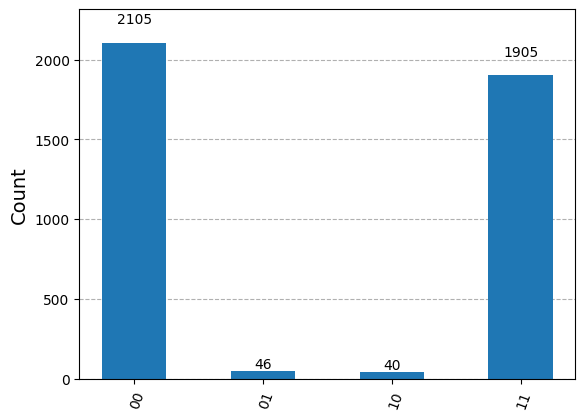

In [17]:
#|phi->
qc = QuantumCircuit(2, 2)
qc.h(0)
qc.cx(0, 1)
qc.z(0)
qc.measure([0, 1], [0, 1])

backend = service.least_busy(simulator=False)
qc_transpiled = transpile(qc, backend=backend)

sampler = Sampler(backend)
job = sampler.run([qc_transpiled])
result = job.result()

counts = result[0].data.c.get_counts()
print("Measurement results:", counts)

plot_histogram(counts)